<a href="https://colab.research.google.com/github/Subiksha-1505/AI-Powered-Early-Learning-Gap-Detection/blob/main/Real_Time_Waste_Segregation_TrashNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub tensorflow matplotlib seaborn scikit-learn pillow opencv-python

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "feyzazkefe/trashnet"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 40.8M/40.8M [00:02<00:00, 18.9MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1


In [ ]:
for root, dirs, files in os.walk(dataset_path):
    if files:
        print(root, "->", len(files), "files")

/root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized/trash -> 137 files
/root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized/paper -> 594 files
/root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized/cardboard -> 403 files
/root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized/metal -> 410 files
/root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized/plastic -> 482 files
/root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized/glass -> 501 files


In [ ]:
class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

dataset_dir = None

for root, dirs, files in os.walk(dataset_path):
    if all(cls in dirs for cls in class_names):
        dataset_dir = root
        break

print("Dataset directory:", dataset_dir)

Dataset directory: /root/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized


In [ ]:
class_counts = {}

for cls in class_names:
    folder = os.path.join(dataset_dir, cls)
    class_counts[cls] = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

print("Dataset distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Dataset distribution:
cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


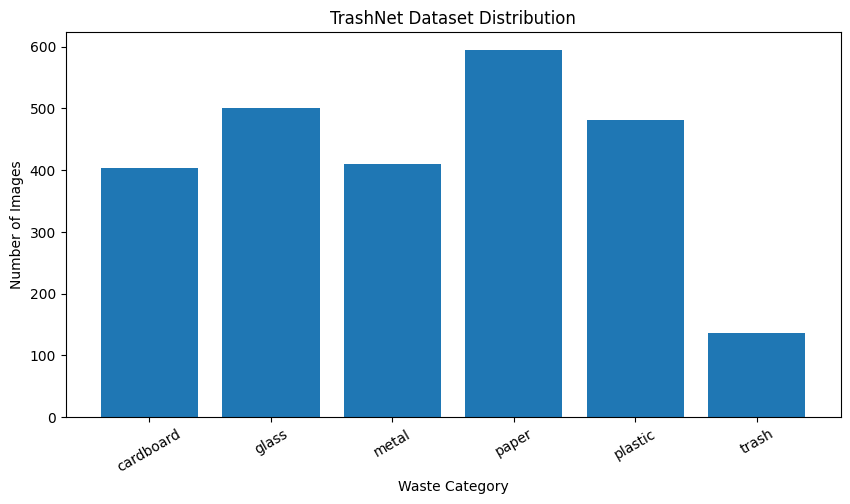

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("TrashNet Dataset Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)
plt.show()

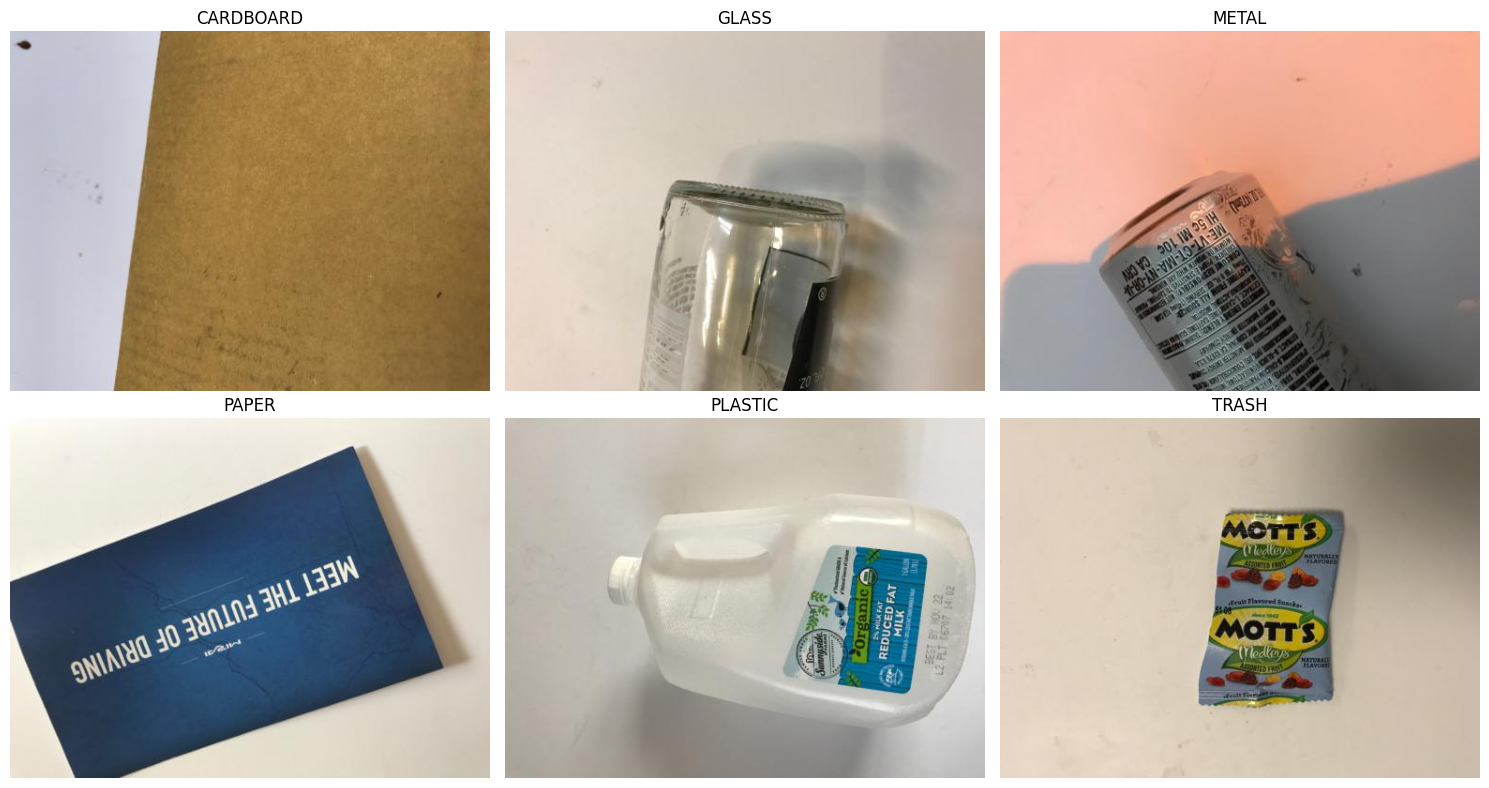

In [ ]:
plt.figure(figsize=(15, 8))

for i, cls in enumerate(class_names):
    folder = os.path.join(dataset_dir, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(folder, images[0])

    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

print("Classes:", train_ds.class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

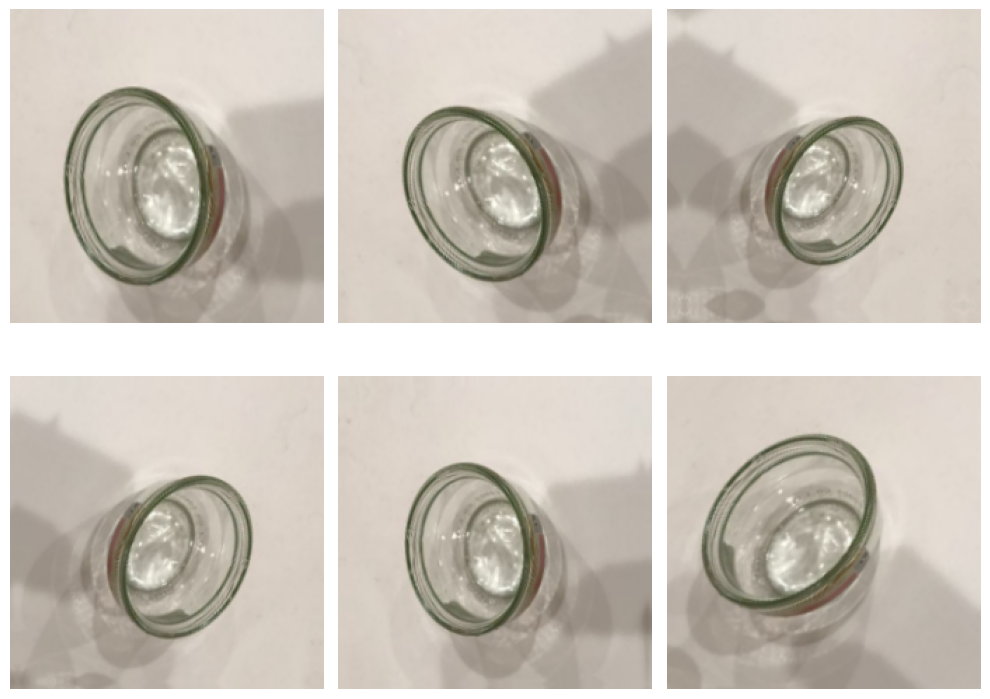

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.10)
])

plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    sample_image = images[0]

    for i in range(6):
        augmented = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )

        plt.subplot(2, 3, i + 1)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(augmented[0], 0, 255),
                tf.uint8
            )
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded successfully.


In [ ]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    6,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.3615 - loss: 1.6411 - val_accuracy: 0.4871 - val_loss: 1.4158
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4441 - loss: 1.4265 - val_accuracy: 0.5564 - val_loss: 1.2444
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4995 - loss: 1.2763 - val_accuracy: 0.6238 - val_loss: 1.1217
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5737 - loss: 1.1488 - val_accuracy: 0.6535 - val_loss: 1.0331
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.5885 - loss: 1.0915 - val_accuracy: 0.6634 - val_loss: 0.9639
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.6286 - loss: 0.9775 - val_accuracy: 0.6851 - val_loss: 0.9077
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.6395 - loss: 0.9545 - val_accuracy: 0.6990 - val_loss: 0.8625
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6741 - loss: 0.8873 - val_accuracy: 0.7069 -

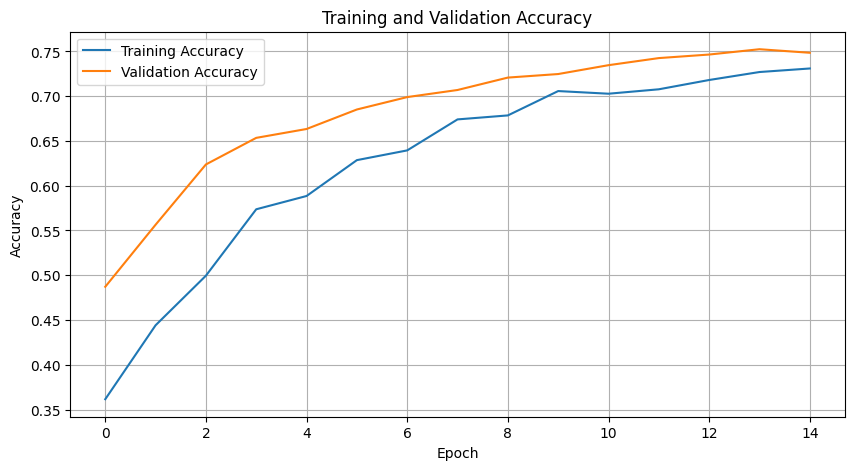

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()
plt.show()

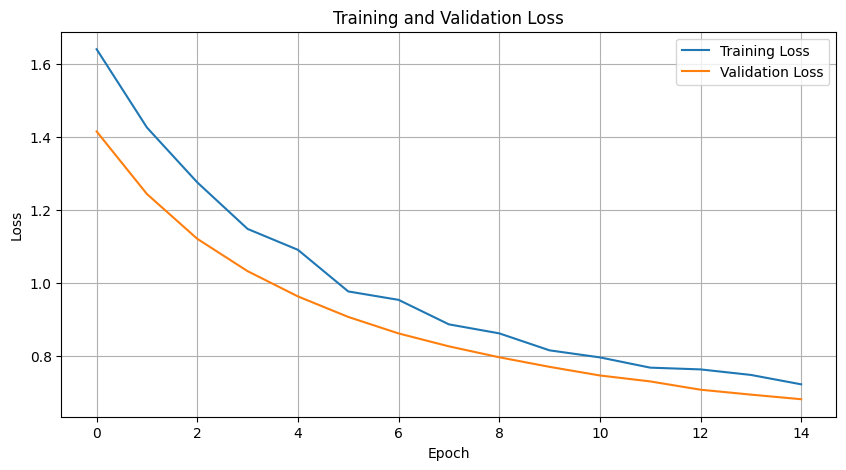

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7485 - loss: 0.6823
Validation Loss: 0.6823
Validation Accuracy: 74.85%


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction completed.")

Prediction completed.


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   cardboard       0.85      0.87      0.86        69
       glass       0.74      0.75      0.74       102
       metal       0.69      0.78      0.73        88
       paper       0.84      0.83      0.84       123
     plastic       0.65      0.69      0.67        89
       trash       0.62      0.29      0.40        34

    accuracy                           0.75       505
   macro avg       0.73      0.70      0.71       505
weighted avg       0.75      0.75      0.74       505



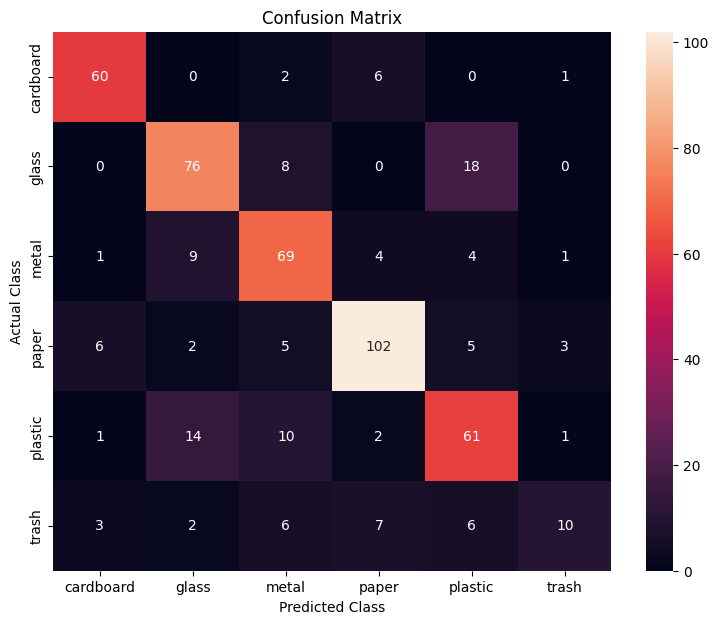

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
model.save("/content/waste_segregation_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download(
    "/content/waste_segregation_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def predict_waste(image):
    image = image.convert("RGB")
    image = image.resize((224, 224))

    img_array = np.array(image)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = prediction[predicted_index] * 100

    return predicted_class, confidence

Saving Screenshot 2026-09-25 093328.png to Screenshot 2026-09-25 093328.png


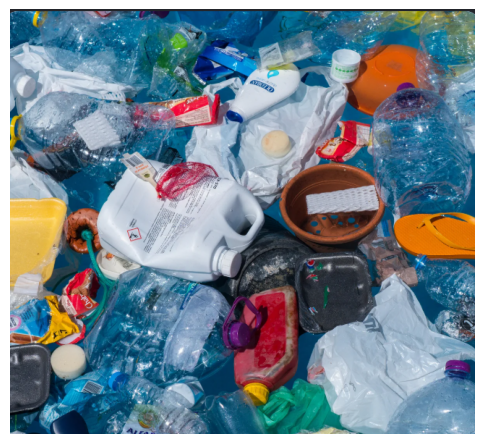

WASTE SEGREGATION RESULT
Predicted Waste : PLASTIC
Confidence      : 92.09%


In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():

    image = Image.open(filename)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    predicted_class, confidence = predict_waste(image)

    print("=" * 50)
    print("WASTE SEGREGATION RESULT")
    print("=" * 50)

    print(f"Predicted Waste : {predicted_class.upper()}")
    print(f"Confidence      : {confidence:.2f}%")

In [ ]:
waste_info = {
    "cardboard": "♻️ Recyclable - Place in the recyclable waste bin.",
    "glass": "♻️ Recyclable - Place in the glass recycling bin.",
    "metal": "♻️ Recyclable - Place in the metal recycling bin.",
    "paper": "♻️ Recyclable - Place in the paper recycling bin.",
    "plastic": "♻️ Recyclable - Place in the plastic recycling bin.",
    "trash": "🗑️ Non-Recyclable - Place in the general waste bin."
}

print(waste_info[predicted_class])

♻️ Recyclable - Place in the plastic recycling bin.


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import io

def take_photo(filename="webcam_photo.jpg", quality=0.8):

    js = Javascript("""
    async function takePhoto(quality) {

        const div = document.createElement('div');

        const video = document.createElement('video');

        const button = document.createElement('button');

        button.textContent = '📸 Capture Waste Image';

        div.appendChild(video);
        div.appendChild(button);

        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;

        await video.play();

        google.colab.output.setIframeHeight(
            document.documentElement.scrollHeight,
            true
        );

        await new Promise((resolve) => {
            button.onclick = resolve;
        });

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0
        );

        stream.getVideoTracks()[0].stop();

        div.remove();

        return canvas.toDataURL(
            'image/jpeg',
            quality
        );
    }
    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    binary = b64decode(
        data.split(',')[1]
    )

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [ ]:
from google.colab._message import MessageError

try:
    filename = take_photo()

    image = Image.open(filename)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
except MessageError as e:
    if "NotAllowedError: Permission denied" in str(e):
        print("Error: Webcam access denied. Please allow camera access in your browser to use the webcam photo feature.")
    else:
        raise e

<IPython.core.display.Javascript object>

Error: Webcam access denied. Please allow camera access in your browser to use the webcam photo feature.


In [ ]:
predicted_class, confidence = predict_waste(image)

print("\n" + "=" * 55)
print("♻️ REAL-TIME WASTE SEGREGATION SYSTEM")
print("=" * 55)

print(f"Detected Waste : {predicted_class.upper()}")
print(f"Confidence     : {confidence:.2f}%")

print("-" * 55)

print(
    waste_info[predicted_class]
)

print("=" * 55)

In [ ]:
from IPython.display import HTML, display

def display_result(image, predicted_class, confidence):

    recommendations = {
        "cardboard": "♻️ Recyclable Waste",
        "glass": "♻️ Recyclable Waste",
        "metal": "♻️ Recyclable Waste",
        "paper": "♻️ Recyclable Waste",
        "plastic": "♻️ Recyclable Waste",
        "trash": "🗑️ Non-Recyclable Waste"
    }

    html = f"""
    <div style="
        width:600px;
        padding:25px;
        border-radius:20px;
        border:2px solid #333;
        text-align:center;
        font-family:Arial;
        margin:auto;
    ">

    <h1>♻️ Real-Time Waste Segregation</h1>

    <h2>Detected Waste</h2>

    <h1 style="font-size:40px;">
        {predicted_class.upper()}
    </h1>

    <h2>
        Confidence: {confidence:.2f}%
    </h2>

    <h3>
        {recommendations[predicted_class]}
    </h3>

    <p>
        Powered by CNN + MobileNetV2 Transfer Learning
    </p>

    </div>
    """

    display(HTML(html))

In [ ]:
display_result(
    image,
    predicted_class,
    confidence
)